# Modules

In [ ]:
import json
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

from longitudinal_arm_swing.constants import *

pd.set_option('display.max_columns', 500)

# Constants

In [3]:
segment_lengths = ['0_20', '20_inf']
filter_type = 'filtered'
measures = ['median', '95p', 'median_cov']

path_measures = os.path.join(BASE_PATH, 'measures', f'{filter_type}_gait')
path_figures_paper = r'C:\Users\z665206\Documents\PhD\docs\papers\ppp\paper\tex\imgs'

pd_med_id_filename = 'pd_med_ids.txt'
pd_no_med_id_filename = 'pd_no_med_ids.txt'
ids_remaining_after_exclusions_filename = 'ids_remaining_after_exclusions.json'
aff_side_ids_filename = 'affected_side_ids.json'

first_week = 2
mid_week = 52
final_week = 100

off_score = 'updrs_3_hypokinesia_off_ws'
on_score = 'updrs_3_hypokinesia_on_ws'

# Load

In [ ]:
signal_interp_vals = {}
for group in ['pd', 'controls']:
    signal_interp_vals[group] = {}
    for segment_length in segment_lengths:
        signal_interp_vals[group][segment_length] = {}
        for measure in measures:
            signal_interp_vals[group][segment_length][measure] = pd.read_csv(os.path.join(path_measures, segment_length, f'{group}_signal_interp_{measure}_range_of_motion.csv'))

df_measures_inclusion = pd.read_parquet(os.path.join(BASE_PATH, 'measures', 'digital_measures.parquet'))

with open(os.path.join(path_measures, '20_inf', 'pd_med_ids.txt'), 'r') as f:
    pd_med_ids = f.read().splitlines()

with open(os.path.join(path_measures, '20_inf', 'pd_no_med_ids.txt'), 'r') as f:
    pd_no_med_ids = f.read().splitlines()

with open(os.path.join(PATH_IDS, ids_remaining_after_exclusions_filename), 'r') as f:
    ids_remaining_after_exclusions = json.load(f)

with open(os.path.join(PATH_IDS, aff_side_ids_filename), 'r') as f:
    aff_side_ids = json.load(f)

with open(os.path.join(PATH_IDS, 'ids_late_visit_3.txt'), 'r') as f:
    ids_late_visit3 = f.read().splitlines()

df_clinical = pd.read_parquet(os.path.join(PATH_CLINICAL_DATA, 'clinical_data.parquet'))

with open(os.path.join(path_measures, 'delta_scores.json'), 'r') as f:
    delta_scores_n_weights = json.load(f)

# Prepare data

### Clinical data

In [ ]:
delta_scores = {
    'mas': {},
    'las': {},
}

regr_ids = ids_remaining_after_exclusions['ppp']['regr'] + ids_remaining_after_exclusions['denovo']['regr']

for j, subject in enumerate(regr_ids):
    if subject in aff_side_ids['ppp']['mas'] + aff_side_ids['denovo']['mas']:
        side = 'mas'
    else:
        side = 'las'

    if subject in pd_med_ids:
        med_state = 'med'
    else:
        med_state = 'no_med'

    group = f'pd_{side}'
    
    df_subject_clinical = df_clinical.loc[df_clinical['id']==subject]
    delta_scores[side][subject] = {}
    visits = df_subject_clinical['visit'].unique()

    if subject not in delta_scores_n_weights['0_20'][f'{group}_{med_state}'][measure][f'dynamic_{final_week}']['ids']:
        del delta_scores[side][subject]
        continue

    for segment_length in segment_lengths:
        delta_scores[side][subject][segment_length] = {}
        for measure in measures:
            df_subject_digital = signal_interp_vals['pd'][segment_length][measure].iloc[pd_med_ids.index(subject)]

            delta_scores[side][subject][segment_length][f'{measure}_12'] = df_subject_digital[f'week{mid_week}'] - df_subject_digital[f'week{first_week}']
            delta_scores[side][subject][segment_length][f'{measure}_13'] = df_subject_digital[f'week{final_week}'] - df_subject_digital[f'week{first_week}']
            delta_scores[side][subject][segment_length][f'{measure}_23'] = df_subject_digital[f'week{final_week}'] - df_subject_digital[f'week{mid_week}']

            delta_scores_n_weights_focus = delta_scores_n_weights['0_20'][f'{group}_{med_state}'][measure][f'dynamic_{final_week}']

            subject_idx = delta_scores_n_weights_focus['ids'].index(subject)
            unweighted_vals = delta_scores_n_weights_focus['unweighted'][subject_idx]
            weighted_vals = delta_scores_n_weights_focus['unweighted'][subject_idx] * delta_scores_n_weights_focus['weights'][subject_idx]

            delta_scores[side][subject][segment_length][f'{measure}_13_weighted'] = weighted_vals

    if 1 in visits:
        ledd_1 = df_subject_clinical.loc[df_subject_clinical['visit']==1, 'ledd'].values[0]
        delta_scores[side][subject]['ledd_1'] = ledd_1

        delta_scores[side][subject]['years_since_diagnosis'] = df_subject_clinical.loc[df_subject_clinical['visit']==1, 'YearsSinceDiagFloat'].values[0]
        delta_scores[side][subject]['at_least_slight_dyskinesia_visit_1'] = df_subject_clinical.loc[df_subject_clinical['visit']==1, 'at_least_slight_dyskinesia'].values[0]
        delta_scores[side][subject]['daily_off_state_hrs_visit_1'] = df_subject_clinical.loc[df_subject_clinical['visit']==1, 'MotComDailyOffState'].values[0]

    else:
        delta_scores[side][subject]['ledd_1'] = np.nan

    if 2 in visits:
        ledd_2 = df_subject_clinical.loc[df_subject_clinical['visit']==2, 'ledd'].values[0]
        delta_scores[side][subject]['ledd_2'] = ledd_2
        delta_scores[side][subject]['at_least_slight_dyskinesia_visit_2'] = df_subject_clinical.loc[df_subject_clinical['visit']==2, 'at_least_slight_dyskinesia'].values[0]
        delta_scores[side][subject]['daily_off_state_hrs_visit_2'] = df_subject_clinical.loc[df_subject_clinical['visit']==2, 'MotComDailyOffState'].values[0]
    else:
        delta_scores[side][subject]['ledd_2'] = np.nan

    if 3 in visits:
        ledd_3 = df_subject_clinical.loc[df_subject_clinical['visit']==3, 'ledd'].values[0]
        delta_scores[side][subject]['ledd_3'] = ledd_3
        delta_scores[side][subject]['at_least_slight_dyskinesia_visit_3'] = df_subject_clinical.loc[df_subject_clinical['visit']==3, 'at_least_slight_dyskinesia'].values[0]
        delta_scores[side][subject]['daily_off_state_hrs_visit_3'] = df_subject_clinical.loc[df_subject_clinical['visit']==3, 'MotComDailyOffState'].values[0]
    else:
        delta_scores[side][subject]['ledd_3'] = np.nan

    if pd.isna(ledd_2):
        delta_scores[side][subject]['ledd_1_2'] = np.nan
    elif pd.isna(ledd_1):
        delta_scores[side][subject]['ledd_1_2'] = ledd_2
    else:
        delta_scores[side][subject]['ledd_1_2'] = ledd_2 - ledd_1

    if pd.isna(ledd_3):
        delta_scores[side][subject]['ledd_2_3'] = np.nan
    elif pd.isna(ledd_2):
        delta_scores[side][subject]['ledd_2_3'] = np.nan
    else:
        delta_scores[side][subject]['ledd_2_3'] = ledd_3 - ledd_2

    if pd.isna(ledd_3):
        delta_scores[side][subject]['ledd_1_3'] = np.nan
    elif pd.isna(ledd_1):
        delta_scores[side][subject]['ledd_1_3'] = ledd_3
    else:
        delta_scores[side][subject]['ledd_1_3'] = ledd_3 - ledd_1

    for score in [off_score, on_score, 'updrs_2_total']:
        if all([x in visits for x in [1, 2]]):
            delta_updrs_12 = df_subject_clinical.loc[df_subject_clinical['visit']==2, score].values[0] - df_subject_clinical.loc[df_subject_clinical['visit']==1, score].values[0]
        else:
            delta_updrs_12 = np.nan

        if all([x in visits for x in [1, 3]]):
            delta_updrs_13 = df_subject_clinical.loc[df_subject_clinical['visit']==3, score].values[0] - df_subject_clinical.loc[df_subject_clinical['visit']==1, score].values[0]
        else:
            delta_updrs_13 = np.nan
        
        if all([x in visits for x in [2, 3]]):
            delta_updrs_23 = df_subject_clinical.loc[df_subject_clinical['visit']==3, score].values[0] - df_subject_clinical.loc[df_subject_clinical['visit']==2, score].values[0]
        else:
            delta_updrs_23 = np.nan

        delta_scores[side][subject][f'{score}_12'] = delta_updrs_12
        delta_scores[side][subject][f'{score}_13'] = delta_updrs_13
        delta_scores[side][subject][f'{score}_23'] = delta_updrs_23


# Regression

In [ ]:
measure = 'median_cov'
segment_length = 'short'
most_affected_side = True

dfs = []
for side in ['mas', 'las']:
    ledd_ids = list(delta_scores[side].keys())

    dfs.append(pd.DataFrame({
        'id': ledd_ids,
        'most_affected_side': [1 if x in delta_scores['mas'] else 0 for x in ledd_ids],
        'delta_ledd': [delta_scores[side][x]['ledd_1_3'] for x in ledd_ids],
        'delta_median_short': [delta_scores[side][x]['0_20']['median_13'] for x in ledd_ids],
        'delta_median_long': [delta_scores[side][x]['20_inf']['median_13'] for x in ledd_ids],
        'delta_95p_short': [delta_scores[side][x]['0_20']['95p_13'] for x in ledd_ids],
        'delta_95p_long': [delta_scores[side][x]['20_inf']['95p_13'] for x in ledd_ids],
        'delta_median_cov_short': [delta_scores[side][x]['0_20']['median_cov_13'] for x in ledd_ids],
        'delta_median_cov_long': [delta_scores[side][x]['20_inf']['median_cov_13'] for x in ledd_ids],
        'years_since_diagnosis': [delta_scores[side][x]['years_since_diagnosis'] for x in ledd_ids],
        'dyskinesia_baseline': [delta_scores[side][x]['at_least_slight_dyskinesia_visit_1'].astype(int) for x in ledd_ids],
        'delta_dyskinesia': [delta_scores[side][x]['at_least_slight_dyskinesia_visit_3'].astype(int) - 
                             delta_scores[side][x]['at_least_slight_dyskinesia_visit_1'].astype(int) for x in ledd_ids],
    }))

df_ols = pd.concat(dfs)

df_ols = df_ols.loc[df_ols['most_affected_side'] == most_affected_side]

target_column = f'delta_{measure}_{segment_length}'
covariates = ['delta_ledd', 'years_since_diagnosis', 'delta_dyskinesia'] # most_affected_side

# for cov in covariates:
#     if cov != "most_affected_side":
#         df_ols[f"{cov}_x_most_affected_side"] = df_ols[cov] * df_ols["most_affected_side"]

nonbinary_covariates = ['delta_ledd', 'years_since_diagnosis', 'delta_dyskinesia']

df_ols_regr = df_ols.dropna(subset=[target_column] + covariates)

y = df_ols_regr[target_column]
X = df_ols_regr[covariates] # + [f"{cov}_x_most_affected_side" for cov in covariates if cov != "most_affected_side"]]
X = sm.add_constant(X) 

model = sm.OLS(y, X).fit()

print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     delta_median_cov_short   R-squared:                       0.085
Model:                                OLS   Adj. R-squared:                  0.069
Method:                     Least Squares   F-statistic:                     5.397
Date:                    Thu, 28 Aug 2025   Prob (F-statistic):            0.00142
Time:                            10:16:58   Log-Likelihood:                 353.29
No. Observations:                     179   AIC:                            -698.6
Df Residuals:                         175   BIC:                            -685.8
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------


Median RoM, Short gait segments
Change in dyskinesia: 0.3587785653 (-0.0231141115, 0.7406712420), p=0.065
Change in LEDD: 0.5411444736 (0.1587079526, 0.9235809946), p=0.006
Years since diagnosis: 0.1533204353 (-0.2299044010, 0.5365452715), p=0.432
Most affected side: 1.9828567363 (1.1928215911, 2.7728918815), p=0.000

Median RoM, Long gait segments
Change in dyskinesia: 0.8021350337 (-0.1616585446, 1.7659286120), p=0.102
Change in LEDD: 0.7846099312 (-0.1805561626, 1.7497760250), p=0.111
Years since diagnosis: 0.1923716476 (-0.7747839403, 1.1595272354), p=0.696
Most affected side: 3.0676147303 (1.0737802161, 5.0614492445), p=0.003

95p RoM, Short gait segments
Change in dyskinesia: 1.8030546525 (0.5978118273, 3.0082974778), p=0.004
Change in LEDD: 1.2349286230 (0.0279694402, 2.4418878058), p=0.045
Years since diagnosis: -0.0044653229 (-1.2139124072, 1.2049817614), p=0.994
Most affected side: 6.2856582099 (3.7923289358, 8.7789874840), p=0.000

95p RoM, Long gait segments
Change in dysk

C:\Users\z665206\AppData\Local\Temp\ipykernel_19928\986151869.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fp_list.append([covariate, model.params[m], model.conf_int()[0].values[m], model.conf_int()[1].values[m], model.pvalues[m]])
C:\Users\z665206\AppData\Local\Temp\ipykernel_19928\986151869.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fp_list.append([covariate, model.params[m], model.conf_int()[0].values[m], model.conf_int()[1].values[m], model.pvalues[m]])
C:\Users\z665206\AppData\Local\Temp\ipykernel_19928\986151869.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated.

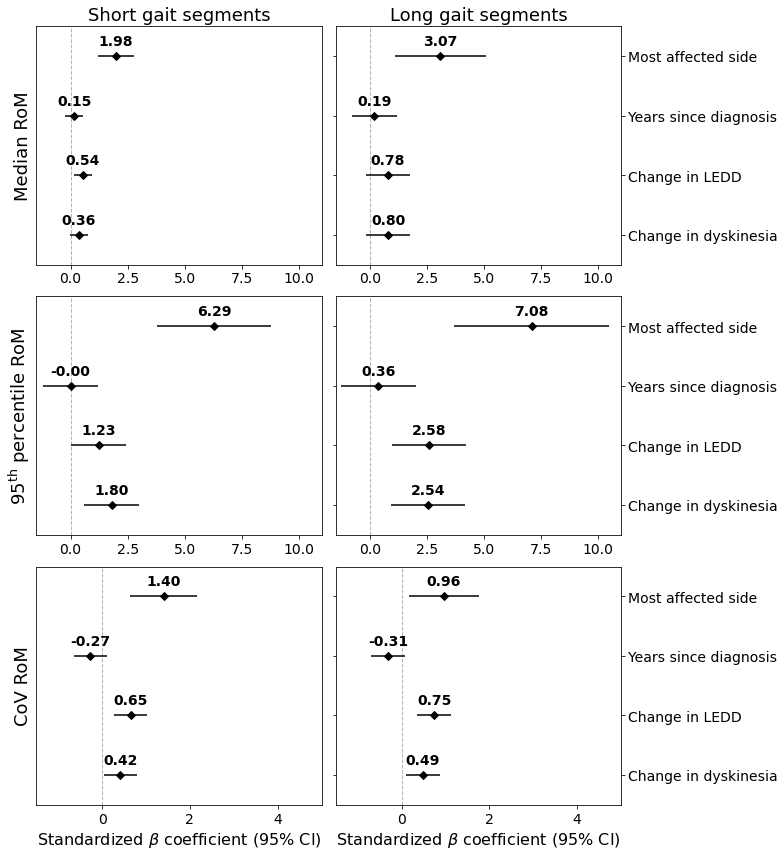

In [ ]:
standardize = True
save_plot = False

df_ols_std = df_ols.copy()
df_ols_std = df_ols_std.dropna(subset=['delta_ledd'])

if standardize:
    xlabel = 'Standardized $\\beta$ coefficient (95% CI)'
    scaler = StandardScaler()
    df_ols_std[nonbinary_covariates] = scaler.fit_transform(df_ols_std[nonbinary_covariates])
else:
    xlabel = 'Coefficients'

map_covariates = {
    # 'most_affected_side': 'Most affected side',
    'years_since_diagnosis': 'Years since diagnosis',
    'delta_ledd': 'Change in LEDD',
    'delta_dyskinesia': 'Change in dyskinesia',
}

fig, ax = plt.subplots(nrows=len(measures), ncols=2, figsize=(11, len(measures) * 4), sharex=False, sharey=True)

for i, measure in enumerate(measures):
    for j, segment_length in enumerate(['short', 'long']):
        print(f'\n{measure.capitalize()} RoM, {segment_length.capitalize()} gait segments')
        y = df_ols_std[f'delta_{measure}_{segment_length}']
        X = df_ols_std[covariates]
        X = sm.add_constant(X) 

        model = sm.OLS(y, X).fit()

        fp_list = []
        for m, covariate in enumerate(X.columns):
            fp_list.append([covariate, model.params[m], model.conf_int()[0].values[m], model.conf_int()[1].values[m], model.pvalues[m]])

        df_ols_plot = pd.DataFrame(fp_list, columns=['covariate', 'coefficient', 'ci_lower', 'ci_upper', 'pvalue'])
        df_ols_plot = df_ols_plot.loc[df_ols_plot['covariate'] != 'const'].reset_index(drop=True)

        df_ols_plot = df_ols_plot[df_ols_plot['covariate'].isin(map_covariates.keys())].copy()
        df_ols_plot['covariate_renamed'] = df_ols_plot['covariate'].map(map_covariates)

        df_ols_plot['sort_order'] = df_ols_plot['covariate'].apply(lambda x: list(map_covariates.keys()).index(x))
        df_ols_plot = df_ols_plot.sort_values('sort_order', ascending=False).reset_index(drop=True)

        df = df_ols_plot.reset_index(drop=True)

        df['y_pos'] = range(len(df))

        # Loop through each row to plot colored bars and error bars
        for _, row in df.iterrows():
            ax[i,j].errorbar(
                x=row['coefficient'],
                y=row['y_pos'],
                xerr=[[row['coefficient'] - row['ci_lower']], [row['ci_upper'] - row['coefficient']]],
                fmt='D',
                color='black',
                markersize=6,
                zorder=3
            )

            ax[i,j].text(
                row['coefficient'],
                row['y_pos'] + 0.25,
                f"{row['coefficient']:.2f}",
                va='center',
                ha='center',
                fontsize=PLOT_TEXTSIZE,
                color='black',
                weight='bold',
                clip_on=True,
                zorder=2
            )

            print(f"{row['covariate_renamed']}: {row['coefficient']:.{decimals}f} ({row['ci_lower']:.{decimals}f}, {row['ci_upper']:.{decimals}f}), p={row['pvalue']:.3f}")

        if i != 2:
            ax[i, j].set_xlim([-1.5, 11])   
        else:
            ax[i, j].set_xlim([-1.5, 5])

        ax[i, j].set_ylim([-0.5, len(df) - 0.5])

        if j == 0:
            ax[i, j].set_ylabel(f'{AGGREGATION_RENAMING[measure]} RoM', fontsize=PLOT_TITLESIZE)
            ax[i, j].tick_params(axis='y', left=False, labelleft=False)
        else:
            ax[i, j].set_yticks(df['y_pos'])
            ax[i, j].set_yticklabels(df['covariate_renamed'], fontsize=PLOT_TICKSIZE)
            ax[i, j].tick_params(axis='y', labelright=True, right=True)
            ax[i, j].yaxis.set_label_position("right")
            
        if i == 0:
            ax[i, j].set_title(f'{segment_length.capitalize()} gait segments', fontsize=PLOT_TITLESIZE)
        elif i == 2:
            ax[i, j].set_xlabel(xlabel, fontsize=PLOT_LABELSIZE)

        ax[i, j].tick_params(axis='x', labelsize=PLOT_TICKSIZE)

        ax[i, j].axvline(x=0, linestyle='--', color='black', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.show()

if save_plot:
    fig.savefig(os.path.join(path_figures_paper, 'r_regr.png'), bbox_inches='tight', dpi=300)


In [ ]:
standardize = True
save_plot = False
side = 'mas'

df_ols_std = df_ols.loc[df_ols['side'] == side].copy()
df_ols_std = df_ols_std.dropna(subset=['delta_ledd'])

if standardize:
    xlabel = 'Standardized $\\beta$ coefficient (95% CI)'
    scaler = StandardScaler()
    df_ols_std[nonbinary_covariates] = scaler.fit_transform(df_ols_std[nonbinary_covariates])
else:
    xlabel = 'Coefficients'

map_covariates = {
    'most_affected_side': 'Most affected side',
    'years_since_diagnosis': 'Years since diagnosis',
    'delta_ledd': 'Change in LEDD',
    'delta_dyskinesia': 'Change in dyskinesia',
}

fig, ax = plt.subplots(nrows=len(measures), ncols=2, figsize=(11, len(measures) * 4), sharex=False, sharey=True)

for i, measure in enumerate(measures):
    for j, segment_length in enumerate(['short', 'long']):
        print(f'\n{measure.capitalize()} RoM, {segment_length.capitalize()} gait segments')
        y = df_ols_std[f'delta_{measure}_{segment_length}']
        X = df_ols_std[covariates]
        X = sm.add_constant(X) 

        model = sm.OLS(y, X).fit()

        fp_list = []
        for m, covariate in enumerate(X.columns):
            fp_list.append([covariate, model.params[m], model.conf_int()[0].values[m], model.conf_int()[1].values[m], model.pvalues[m]])

        df_ols_plot = pd.DataFrame(fp_list, columns=['covariate', 'coefficient', 'ci_lower', 'ci_upper', 'pvalue'])
        df_ols_plot = df_ols_plot.loc[df_ols_plot['covariate'] != 'const'].reset_index(drop=True)

        df_ols_plot = df_ols_plot[df_ols_plot['covariate'].isin(map_covariates.keys())].copy()
        df_ols_plot['covariate_renamed'] = df_ols_plot['covariate'].map(map_covariates)

        df_ols_plot['sort_order'] = df_ols_plot['covariate'].apply(lambda x: list(map_covariates.keys()).index(x))
        df_ols_plot = df_ols_plot.sort_values('sort_order', ascending=False).reset_index(drop=True)

        df = df_ols_plot.reset_index(drop=True)

        df['y_pos'] = range(len(df))

        # Loop through each row to plot colored bars and error bars
        for _, row in df.iterrows():
            ax[i,j].errorbar(
                x=row['coefficient'],
                y=row['y_pos'],
                xerr=[[row['coefficient'] - row['ci_lower']], [row['ci_upper'] - row['coefficient']]],
                fmt='D',
                color='black',
                markersize=6,
                zorder=3
            )

            ax[i,j].text(
                row['coefficient'],
                row['y_pos'] + 0.25,
                f"{row['coefficient']:.2f}",
                va='center',
                ha='center',
                fontsize=PLOT_TEXTSIZE,
                color='black',
                weight='bold',
                clip_on=True,
                zorder=2
            )

            print(f"{row['covariate_renamed']}: {row['coefficient']:.{decimals}f} ({row['ci_lower']:.{decimals}f}, {row['ci_upper']:.{decimals}f}), p={row['pvalue']:.3f}")

        if i != 2:
            ax[i, j].set_xlim([-1.5, 11])   
        else:
            ax[i, j].set_xlim([-1.5, 5])

        ax[i, j].set_ylim([-0.5, len(df) - 0.5])

        if j == 0:
            ax[i, j].set_ylabel(f'{AGGREGATION_RENAMING[measure]} RoM', fontsize=PLOT_TITLESIZE)
            ax[i, j].tick_params(axis='y', left=False, labelleft=False)
        else:
            ax[i, j].set_yticks(df['y_pos'])
            ax[i, j].set_yticklabels(df['covariate_renamed'], fontsize=PLOT_TICKSIZE)
            ax[i, j].tick_params(axis='y', labelright=True, right=True)
            ax[i, j].yaxis.set_label_position("right")
            
        if i == 0:
            ax[i, j].set_title(f'{segment_length.capitalize()} gait segments', fontsize=PLOT_TITLESIZE)
        elif i == 2:
            ax[i, j].set_xlabel(xlabel, fontsize=PLOT_LABELSIZE)

        ax[i, j].tick_params(axis='x', labelsize=PLOT_TICKSIZE)

        ax[i, j].axvline(x=0, linestyle='--', color='black', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.show()

if save_plot:
    fig.savefig(os.path.join(path_figures_paper, 'r_regr.png'), bbox_inches='tight', dpi=300)


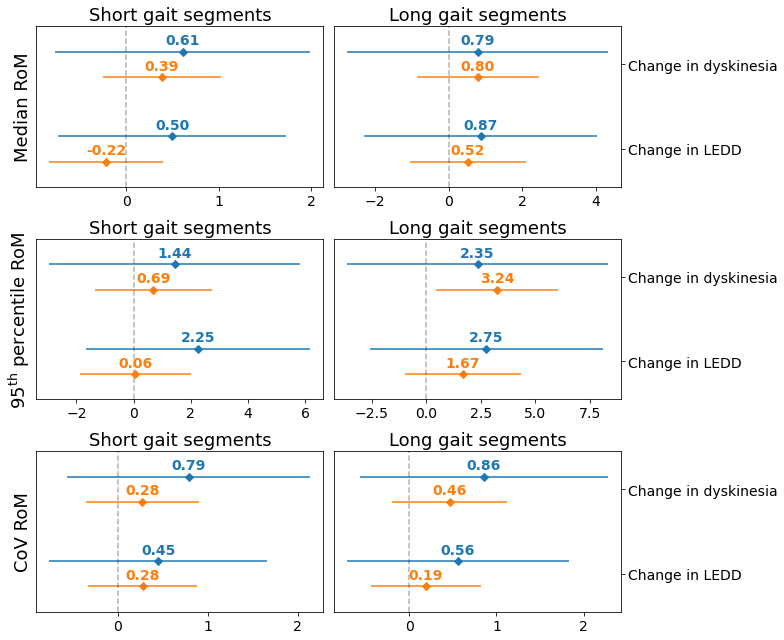

In [ ]:
standardize = True

dfs = []
for side in ['mas', 'las']:
    ledd_ids = list(delta_scores[side].keys())

    dfs.append(pd.DataFrame({
        'id': ledd_ids,
        'most_affected_side': [1 if x in delta_scores['mas'] else 0 for x in ledd_ids],
        'delta_ledd': [delta_scores[side][x]['ledd_1_3'] for x in ledd_ids],
        'delta_median_short': [delta_scores[side][x]['0_20']['median_13'] for x in ledd_ids],
        'delta_median_long': [delta_scores[side][x]['20_inf']['median_13'] for x in ledd_ids],
        'delta_95p_short': [delta_scores[side][x]['0_20']['95p_13'] for x in ledd_ids],
        'delta_95p_long': [delta_scores[side][x]['20_inf']['95p_13'] for x in ledd_ids],
        'delta_median_cov_short': [delta_scores[side][x]['0_20']['median_cov_13'] * 100 for x in ledd_ids],
        'delta_median_cov_long': [delta_scores[side][x]['20_inf']['median_cov_13'] * 100 for x in ledd_ids],
        'years_since_diagnosis': [delta_scores[side][x]['years_since_diagnosis'] for x in ledd_ids],
        # 'dyskinesia_baseline': [delta_scores[side][x]['at_least_slight_dyskinesia_visit_1'].astype(int) for x in ledd_ids],
        'delta_dyskinesia': [delta_scores[side][x]['at_least_slight_dyskinesia_visit_3'].astype(int) - 
                             delta_scores[side][x]['at_least_slight_dyskinesia_visit_1'].astype(int) for x in ledd_ids],
    }))

df_ols = pd.concat(dfs)

covariates = ['most_affected_side', 'years_since_diagnosis', 'delta_ledd', 'delta_dyskinesia']

for cov in covariates:
    if cov != "most_affected_side":
        df_ols[f"{cov}_x_most_affected_side"] = df_ols[cov] * df_ols["most_affected_side"]

# mark which ones to standardize
nonbinary_covariates = [
    'delta_ledd', 
    'years_since_diagnosis',
    'delta_dyskinesia',
    'delta_ledd_x_most_affected_side',
    'years_since_diagnosis_x_most_affected_side',
    'delta_dyskinesia_x_most_affected_side'
]

df_ols_std = df_ols.copy()
df_ols_std = df_ols_std.dropna(subset=['delta_ledd'])

if standardize:
    xlabel = 'Standardized $\\beta$\ncoefficient (95% CI)'
    scaler = StandardScaler()
    df_ols_std[nonbinary_covariates] = scaler.fit_transform(df_ols_std[nonbinary_covariates])
else:
    xlabel = 'Coefficients'

map_covariates = {
    # 'most_affected_side': 'Most affected side',
    # 'years_since_diagnosis': 'Years since diagnosis',
    'delta_ledd': 'Change in LEDD',
    'delta_dyskinesia': 'Change in dyskinesia',
    # 'years_since_diagnosis_x_most_affected_side': 'Years since diagnosis × Most affected side',
    'delta_ledd_x_most_affected_side': 'LEDD × Most affected side',
    'delta_dyskinesia_x_most_affected_side': 'Dyskinesia × Most affected side',
}

plot_covs = ['delta_ledd', 'delta_dyskinesia']

plot_rows = []
for i, measure in enumerate(measures):
    for j, segment_length in enumerate(['short', 'long']):
        y = df_ols_std[f'delta_{measure}_{segment_length}']

        X = df_ols_std[covariates + [f"{cov}_x_most_affected_side" for cov in covariates if cov != "most_affected_side"]]
        X = sm.add_constant(X) 

        model = sm.OLS(y, X).fit()

        for cov in plot_covs:
            coef_mas = model.params[cov] + model.params[f"{cov}_x_most_affected_side"]
            ci_mas = (
                model.conf_int().loc[cov, 0] + model.conf_int().loc[f"{cov}_x_most_affected_side", 0],
                model.conf_int().loc[cov, 1] + model.conf_int().loc[f"{cov}_x_most_affected_side", 1]
            )
            coef_las = model.params[cov]
            ci_las = model.conf_int().loc[cov]
            
            plot_rows.append({
                'measure': measure,
                'segment_length': segment_length,
                'covariate': cov,
                'side': 'mas',
                'coefficient': coef_mas,
                'ci_lower': ci_mas[0],
                'ci_upper': ci_mas[1],
            })
            plot_rows.append({
                'measure': measure,
                'segment_length': segment_length,
                'covariate': cov,
                'side': 'las',
                'coefficient': coef_las,
                'ci_lower': ci_las[0],
                'ci_upper': ci_las[1],
            })

df_plot = pd.DataFrame(plot_rows)
df_plot['covariate_renamed'] = df_plot['covariate'].map(map_covariates)

fig, ax = plt.subplots(nrows=len(measures), ncols=2, figsize=(11, len(measures)*3), sharex=False, sharey=False)

for i, measure in enumerate(measures):
    for j, segment_length in enumerate(['short', 'long']):
        df_sub = df_plot[(df_plot['measure'] == measure) & (df_plot['segment_length'] == segment_length)].copy()
        
        cov_order = ['delta_ledd', 'delta_dyskinesia'] 
        cov_to_y = {cov: i for i, cov in enumerate(reversed(cov_order))}  
        df_sub['y_pos'] = df_sub['covariate'].map(cov_to_y)
        
        y_offsets = {'mas': 0.15, 'las': -0.15}
        df_sub['y_pos_offset'] = df_sub.apply(lambda row: row['y_pos'] + y_offsets[row['side']], axis=1)
        
        for _, row in df_sub.iterrows():
            y = row['y_pos'] + y_offsets[row['side']]
            color = 'tab:blue' if row['side'] == 'mas' else 'tab:orange'
            
            ax[i, j].errorbar(
                x=row['coefficient'],
                y=row['y_pos_offset'],
                xerr=[[row['coefficient'] - row['ci_lower']], [row['ci_upper'] - row['coefficient']]],
                fmt='D',
                color=color,
                markersize=6
            )
            ax[i, j].text(
                row['coefficient'],
                y + 0.05,
                f"{row['coefficient']:.2f}",
                ha='center', va='bottom', fontsize=PLOT_TEXTSIZE, color=color, weight='bold',
            )
        
        if j == 0:
            ax[i, j].set_ylabel(f'{AGGREGATION_RENAMING[measure]} RoM', fontsize=PLOT_TITLESIZE)
            ax[i, j].tick_params(axis='y', left=False, labelleft=False)
        else:
            ax[i, j].tick_params(axis='y', left=False, labelleft=False, labelright=True, right=True)
            ax[i, j].yaxis.set_label_position("right")
            ax[i, j].set_yticks(range(len(plot_covs)))
            ax[i, j].set_yticklabels([map_covariates[cov] for cov in plot_covs], fontsize=PLOT_TICKSIZE)

        y_min = df_sub['y_pos_offset'].min() - 0.3  # extra space at bottom
        y_max = df_sub['y_pos_offset'].max() + 0.3  # extra space at top
        ax[i, j].set_ylim([y_min, y_max])
        ax[i, j].tick_params(axis='x', labelsize=PLOT_TICKSIZE)
        ax[i, j].axvline(x=0, color='black', linestyle='--', alpha=0.3)
        ax[i, j].set_title(f"{segment_length.capitalize()} gait segments", fontsize=PLOT_TITLESIZE)

plt.tight_layout()
plt.show()